# 🏠 Tableau de bord interactif — Marché immobilier américain (Trulia, Sept–Oct 2019)
### Projet de module : Visualisation des Données — Bac+2

**Dataset Kaggle utilisé :** `marketing_sample_for_trulia_com-real_estate` — 30 006 annonces immobilières scrapées sur Trulia.com entre le 01/09/2019 et le 31/10/2019, couvrant 34 états et 676 villes des États-Unis.

---

## 1. Contexte et problématique

Le marché immobilier américain est très hétérogène : les prix et les caractéristiques des biens (surface, nombre de chambres, année de construction...) varient fortement selon les villes et les états. Pour une agence, un investisseur ou un futur acquéreur, il est essentiel de comprendre **quels facteurs expliquent le prix d'un bien** et **comment ce marché se structure géographiquement**.

> **Problématique retenue :**
> *Quels sont les principaux facteurs qui influencent le prix des biens immobiliers annoncés sur Trulia à l'automne 2019, et dans quelle mesure une analyse par échantillonnage permet-elle de dégager des tendances fiables à partir de ces 30 000 annonces ?*

### Objectifs du notebook
1. Explorer, nettoyer et comprendre le dataset brut.
2. Construire **5 échantillons** représentatifs du dataset, chacun obtenu par une méthode d'échantillonnage différente (aléatoire simple, stratifié, systématique, en grappes, par quotas).
3. Pour **chaque échantillon**, produire une analyse exploratoire complète : visualisations univariées, bivariées et multivariées, en appliquant les principes de *Data-Ink Ratio*, d'attributs pré-attentifs et de hiérarchie visuelle.
4. Comparer les 5 méthodes d'échantillonnage entre elles et par rapport à la population totale (représentativité, biais).
5. Construire un **tableau de bord interactif** (Streamlit) exploitant ces résultats.

### Plan
1. Chargement et inspection des données
2. Nettoyage des données manquantes et aberrantes
3. Compréhension des variables
4. Rappel théorique sur les 5 méthodes d'échantillonnage
5. Fonction générique d'analyse exploratoire (univariée / bivariée / multivariée)
6. Application aux 5 échantillons
7. Comparaison des méthodes d'échantillonnage
8. Synthèse, limites et recommandations
9. Tableau de bord interactif (code Streamlit à exécuter en dehors du notebook)


## 1. Chargement et inspection des données

### 1.1 Bibliothèques utilisées

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

%matplotlib inline
sns.set_theme(style="white", context="notebook")

# Palette de couleurs coherente utilisee dans tout le notebook (accessibilite + coherence visuelle)
COULEUR_PRINCIPALE = "#2E5EAA"   # bleu -> valeurs "normales"
COULEUR_ACCENT     = "#E8703A"   # orange -> mise en evidence (attribut pre-attentif)
PALETTE_CATEGORIES = sns.color_palette(
    [COULEUR_PRINCIPALE, "#6FA8DC", "#93C47D", "#D5A6BD", "#F1C232", "#8E7CC3"]
)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

print("Bibliotheques chargees avec succes.")


Bibliotheques chargees avec succes.


### 1.2 Chargement du dataset

Le fichier brut contient 68 colonnes, dont un grand nombre ne sont pas exploitables pour l'analyse
(URLs d'images, coordonnées d'agents immobiliers, liens de contact, etc.). On ne charge donc que les
colonnes utiles à la problématique.

In [2]:
# Colonnes conservees pour l'analyse (on ecarte : URLs, images, contacts agents, textes libres...)
colonnes_utiles = [
    'Uniq Id', 'Price', 'Sqr Ft', 'Longitude', 'Latitude', 'Lot Size', 'Beds', 'Bath',
    'Year Built', 'Price Sqr Ft', 'Last Sold Year', 'Last Sold For', 'City', 'State',
    'Zipcode', 'Days On Trulia'
]

df = pd.read_csv(r"C:\Users\ùoj\Desktop\meryeme project\marketing_sample_for_trulia_com-real_estate__20190901_20191031__30k_data.csv", usecols=colonnes_utiles, low_memory=False)

print("Dimensions du dataset brut :", df.shape)
df.head()


Dimensions du dataset brut : (30006, 16)


,Uniq Id,Price,Sqr Ft,Longitude,Latitude,Lot Size,Beds,Bath,Year Built,Price Sqr Ft,Last Sold Year,Last Sold For,City,State,Zipcode,Days On Trulia
0,d6521bac40600f17287f0a5a8b3efc8d,"$895,900","3,447 sqft",-112.081985,33.560055,"7,895 sqft",4.0,4.5,2019.0,$260/sqft,NaN,NaN,Phoenix,AZ,85021.0,110.0
1,659d62537d940a76e3349bd39a72bd92,"$247,000","1,767 sqft",-96.676250,32.829227,"7,877 sqft",3.0,2.0,1954.0,$140/sqft,NaN,NaN,Dallas,TX,75228.0,126.0
2,a003f7017e34b3c8486ffd54cecf9f0d,"$44,900","1,232 sqft",-78.825190,42.913000,"3,510 sqft",3.0,1.0,1900.0,$36/sqft,NaN,NaN,Buffalo,NY,14211.0,44.0
3,bfee8b2ccc4ceaa91ebd92379b9ab73c,"$959,000","1,417 sqft",-73.860170,40.722960,"2,598 sqft",3.0,2.0,1939.0,$677/sqft,2009.0,"$532,000",Flushing,NY,11374.0,2.0
4,01078a918e94a5d7975c66f9f679727a,"$83,500",440 sqft,-80.206314,25.937965,NaN,NaN,1.0,1971.0,$190/sqft,2007.0,"$52,000",Miami Gardens,FL,33169.0,NaN


In [3]:
# Inspection generale : types de donnees, memoire, valeurs non nulles
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30006 entries, 0 to 30005
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Uniq Id         30006 non-null  str    
 1   Price           30006 non-null  str    
 2   Sqr Ft          27786 non-null  str    
 3   Longitude       30006 non-null  float64
 4   Latitude        30006 non-null  float64
 5   Lot Size        25490 non-null  str    
 6   Beds            27420 non-null  float64
 7   Bath            27496 non-null  float64
 8   Year Built      26258 non-null  float64
 9   Price Sqr Ft    27271 non-null  str    
 10  Last Sold Year  14213 non-null  float64
 11  Last Sold For   14213 non-null  str    
 12  City            30006 non-null  str    
 13  State           30006 non-null  str    
 14  Zipcode         30003 non-null  float64
 15  Days On Trulia  24844 non-null  float64
dtypes: float64(8), str(8)
memory usage: 6.0 MB


In [4]:
# Statistiques descriptives des colonnes numeriques (avant nettoyage)
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
Longitude,30006.0,-95.167341,15.454027,-150.047160,-106.742751,-93.390977,-81.638904,-70.997740
Latitude,30006.0,36.158007,5.500075,25.550295,32.747084,36.016481,40.017658,61.442024
Beds,27420.0,3.288658,1.472238,1.000000,3.000000,3.000000,4.000000,65.000000
Bath,27496.0,2.578688,1.448891,0.750000,2.000000,2.000000,3.000000,98.000000
Year Built,26258.0,1973.140224,34.512400,1800.000000,1950.000000,1978.000000,2004.000000,2019.000000
Last Sold Year,14213.0,2011.110673,6.596002,1987.000000,2006.000000,2013.000000,2017.000000,2019.000000
Zipcode,30003.0,59349.268440,27206.130444,2108.000000,33137.000000,68124.000000,85016.000000,99587.000000
Days On Trulia,24844.0,67.727459,65.249994,2.000000,7.000000,44.000000,121.000000,180.000000


### 1.3 Premier constat sur la qualité des données

On remarque immédiatement que plusieurs colonnes censées être numériques (`Price`, `Sqr Ft`, `Lot Size`,
`Price Sqr Ft`, `Last Sold For`) sont en réalité stockées **en texte**, avec des symboles `$`, des virgules
de milliers, des unités (`sqft`, `acres`, `/mo`) ou des mentions non numériques (`Contact For Price`).
Une étape de nettoyage est donc indispensable avant toute analyse.

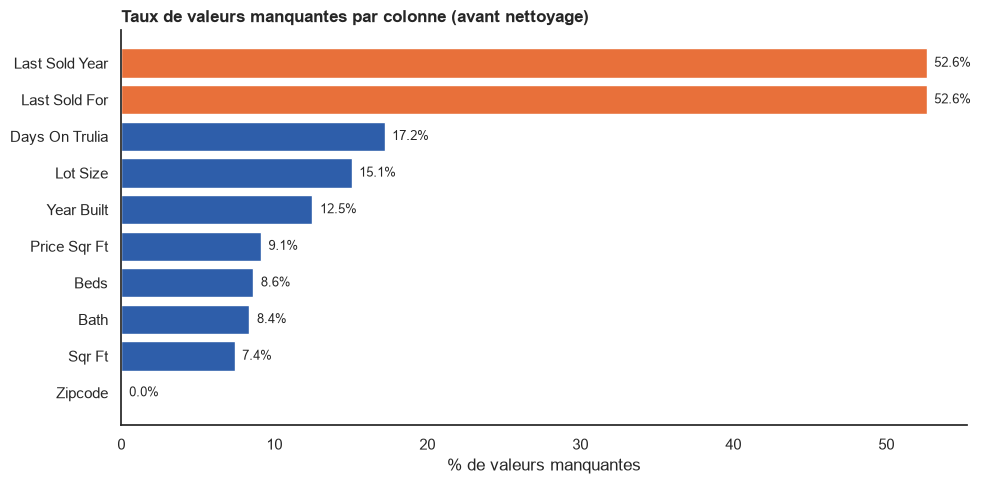

In [5]:
# Visualisation des valeurs manquantes par colonne (avant nettoyage)
fig, ax = plt.subplots(figsize=(10, 5))
taux_manquant = df.isna().mean().sort_values(ascending=False) * 100
taux_manquant = taux_manquant[taux_manquant > 0]
couleurs = [COULEUR_ACCENT if v > 50 else COULEUR_PRINCIPALE for v in taux_manquant.values]
ax.barh(taux_manquant.index[::-1], taux_manquant.values[::-1], color=couleurs[::-1])
ax.set_xlabel("% de valeurs manquantes")
ax.set_title("Taux de valeurs manquantes par colonne (avant nettoyage)", fontsize=12, fontweight='bold', loc='left')
sns.despine(ax=ax)
for i, v in enumerate(taux_manquant.values[::-1]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 2. Nettoyage des données manquantes et aberrantes

Le nettoyage se déroule en 4 temps :
1. **Conversion des colonnes texte en numérique** (`Price`, `Sqr Ft`, `Lot Size`, `Price Sqr Ft`, `Last Sold For`).
2. **Détection des annonces de location** (prix affiché en `$.../mo`) mélangées aux annonces de vente, à exclure de l'analyse des prix de vente.
3. **Traitement des valeurs aberrantes** (ex. 65 chambres, terrains de 500 millions de sqft...) via des bornes réalistes par variable.
4. **Suppression des lignes incomplètes** sur les variables essentielles à l'analyse.

In [6]:
# --- 2.1 Conversion des colonnes texte -> numerique ---

# Price : on repere d'abord les annonces de LOCATION ("$1,200/mo") pour les isoler des ventes
df['Est_Location'] = df['Price'].astype(str).str.contains('/mo', na=False)

prix_nettoye = (
    df['Price'].astype(str)
    .str.replace(r'[\$,+]', '', regex=True)   # supprime $, virgules et "+"
    .str.replace('/mo', '', regex=False)
)
df['Price'] = pd.to_numeric(prix_nettoye, errors='coerce')  # "Contact For Price" -> NaN

# Sqr Ft : "1,725 sqft" -> 1725.0
df['Sqr Ft'] = pd.to_numeric(
    df['Sqr Ft'].astype(str).str.replace(',', '', regex=False).str.replace('sqft', '', regex=False),
    errors='coerce'
)

# Lot Size : unites melangees ("0.41 acres" vs "5,227 sqft") -> tout convertir en sqft
def convertir_lot_size(valeur):
    if pd.isna(valeur):
        return np.nan
    v = str(valeur).lower().strip().replace(',', '')
    try:
        if 'acre' in v:
            return float(v.replace('acres', '').replace('acre', '').strip()) * 43560.0  # 1 acre = 43560 sqft
        elif 'sqft' in v:
            return float(v.replace('sqft', '').strip())
        return np.nan
    except ValueError:
        return np.nan

df['Lot Size Sqft'] = df['Lot Size'].apply(convertir_lot_size)

# Price Sqr Ft : "$175/sqft" -> 175.0
df['Price Sqr Ft'] = pd.to_numeric(
    df['Price Sqr Ft'].astype(str).str.replace(r'[\$/sqft]', '', regex=True), errors='coerce'
)

# Last Sold For : "$239,900" -> 239900.0
df['Last Sold For'] = pd.to_numeric(
    df['Last Sold For'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce'
)

print(f"Annonces de location detectees (a exclure de l'analyse des prix de vente) : {df['Est_Location'].sum()}")
df[['Price', 'Sqr Ft', 'Lot Size Sqft', 'Price Sqr Ft', 'Last Sold For']].describe().T


Annonces de location detectees (a exclure de l'analyse des prix de vente) : 1


,count,mean,std,min,25%,50%,75%,max
Price,29779.0,529807.296115,1.141219e+06,1.0,185000.0,309900.0,534500.0,60000000.0
Sqr Ft,27786.0,5082.979414,2.484791e+05,1.0,1286.0,1800.0,2544.0,36003799.0
Lot Size Sqft,25490.0,93343.350333,4.898516e+06,1.0,4700.0,7405.0,12632.4,550266472.8
Price Sqr Ft,26698.0,216.473107,1.642093e+02,0.0,118.0,165.0,255.0,999.0
Last Sold For,14213.0,346946.728910,1.187349e+06,1.0,113000.0,209800.0,376000.0,120000000.0


In [7]:
# --- 2.2 Traitement des valeurs aberrantes ---
# Bornes definies a partir de la connaissance metier (immobilier residentiel US)
bornes_realistes = {
    'Price':          (10_000, 10_000_000),   # exclut typos ($1) et outliers de luxe extreme
    'Sqr Ft':         (200, 15_000),
    'Beds':           (1, 10),                # 65 chambres = erreur de saisie
    'Bath':           (1, 10),
    'Year Built':     (1800, 2019),
    'Lot Size Sqft':  (500, 500_000),
    'Price Sqr Ft':   (10, 1000),
}

recap_aberrants = []
for colonne, (borne_min, borne_max) in bornes_realistes.items():
    masque_aberrant = (df[colonne] < borne_min) | (df[colonne] > borne_max)
    recap_aberrants.append({'Variable': colonne, 'Bornes valides': f"[{borne_min:,} ; {borne_max:,}]",
                             'Valeurs aberrantes -> NaN': int(masque_aberrant.sum())})
    df.loc[masque_aberrant, colonne] = np.nan

# On retire egalement les annonces de location reperees a l'etape precedente
df = df[~df['Est_Location']].copy()

pd.DataFrame(recap_aberrants)


,Variable,Bornes valides,Valeurs aberrantes -> NaN
0,Price,"[10,000 ; 10,000,000]",261
1,Sqr Ft,"[200 ; 15,000]",181
2,Beds,[1 ; 10],48
3,Bath,[1 ; 10],38
4,Year Built,"[1,800 ; 2,019]",0
5,Lot Size Sqft,"[500 ; 500,000]",446
6,Price Sqr Ft,"[10 ; 1,000]",238


In [8]:
# --- 2.3 Suppression des lignes incompletes sur les variables essentielles a l'analyse ---
variables_essentielles = ['Price', 'Sqr Ft', 'Beds', 'Bath', 'State', 'City', 'Latitude', 'Longitude']

taille_avant = len(df)
df_propre = df.dropna(subset=variables_essentielles).reset_index(drop=True)
taille_apres = len(df_propre)

print(f"Lignes avant nettoyage complet : {taille_avant:,}")
print(f"Lignes apres nettoyage complet : {taille_apres:,}  ({taille_apres/taille_avant:.1%} conservees)")
print(f"\nCeci constitue notre POPULATION D'ETUDE (df_propre), a partir de laquelle")
print(f"les 5 echantillons seront tires dans la suite du notebook.")

df_propre[['Price', 'Sqr Ft', 'Beds', 'Bath', 'Year Built', 'Price Sqr Ft']].describe().T


Lignes avant nettoyage complet : 30,005
Lignes apres nettoyage complet : 26,376  (87.9% conservees)

Ceci constitue notre POPULATION D'ETUDE (df_propre), a partir de laquelle
les 5 echantillons seront tires dans la suite du notebook.


,count,mean,std,min,25%,50%,75%,max
Price,26376.0,503864.711480,672915.141191,10000.0,200000.0,323594.5,545000.0,10000000.0
Sqr Ft,26376.0,2087.942865,1214.810386,290.0,1293.0,1798.0,2525.0,15000.0
Beds,26376.0,3.263952,1.150716,1.0,3.0,3.0,4.0,10.0
Bath,26376.0,2.571768,1.178065,1.0,2.0,2.0,3.0,10.0
Year Built,24559.0,1974.130217,33.994115,1800.0,1951.0,1979.0,2004.0,2019.0
Price Sqr Ft,25657.0,218.517637,161.586160,10.0,120.0,166.0,255.0,999.0


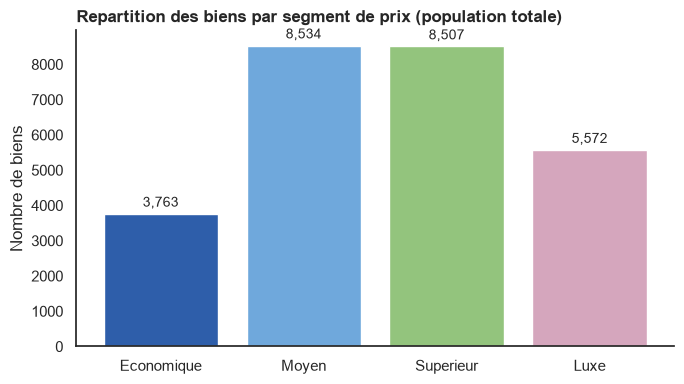

In [9]:
# Segment de prix (utilise plus loin pour l'echantillonnage par quotas et pour le storytelling)
def segmenter_prix(prix):
    if prix < 150_000:
        return 'Economique'
    elif prix < 300_000:
        return 'Moyen'
    elif prix < 600_000:
        return 'Superieur'
    else:
        return 'Luxe'

df_propre['Segment Prix'] = df_propre['Price'].apply(segmenter_prix)
df_propre['Segment Prix'] = pd.Categorical(df_propre['Segment Prix'],
                                            categories=['Economique', 'Moyen', 'Superieur', 'Luxe'], ordered=True)

fig, ax = plt.subplots(figsize=(7, 4))
compte_segments = df_propre['Segment Prix'].value_counts().sort_index()
ax.bar(compte_segments.index.astype(str), compte_segments.values, color=PALETTE_CATEGORIES[:4])
for i, v in enumerate(compte_segments.values):
    ax.text(i, v + 200, f"{v:,}", ha='center', fontsize=10)
ax.set_title("Repartition des biens par segment de prix (population totale)", fontsize=12, fontweight='bold', loc='left')
ax.set_ylabel("Nombre de biens")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


## 3. Compréhension des variables

| Variable | Type | Description |
|---|---|---|
| `Price` | Numérique (continue) | Prix de vente affiché ($) |
| `Sqr Ft` | Numérique (continue) | Surface habitable (sqft) |
| `Lot Size Sqft` | Numérique (continue) | Surface du terrain, convertie en sqft |
| `Beds` | Numérique (discrète) | Nombre de chambres |
| `Bath` | Numérique (discrète) | Nombre de salles de bain |
| `Year Built` | Numérique (discrète) | Année de construction |
| `Price Sqr Ft` | Numérique (continue) | Prix au sqft ($/sqft) |
| `Last Sold For` | Numérique (continue) | Dernier prix de vente connu ($) |
| `Days On Trulia` | Numérique (discrète) | Nombre de jours depuis la mise en ligne |
| `City`, `State`, `Zipcode` | Catégorielle | Localisation du bien |
| `Latitude`, `Longitude` | Numérique (continue) | Coordonnées géographiques |
| `Segment Prix` | Catégorielle ordonnée | Créée à partir de `Price` (Économique/Moyen/Supérieur/Luxe) |

**Relations potentielles à explorer :** `Price` vs `Sqr Ft` (relation attendue positive), `Price` vs `Beds`/`Bath`,
variation géographique du prix par `State`/`City`, effet de l'ancienneté (`Year Built`) sur le prix.

> ℹ️ La colonne d'origine `Property Type` a été écartée : elle contient **99,7 % de valeurs manquantes**
> dans le fichier brut et n'est donc pas exploitable.

In [10]:
print("Nombre d'etats representes :", df_propre['State'].nunique())
print("Nombre de villes representees :", df_propre['City'].nunique())
print(f"\nPeriode couverte par 'Days On Trulia' : 0 a {df_propre['Days On Trulia'].max():.0f} jours (plafonne a 180 par Trulia)")


Nombre d'etats representes : 34
Nombre de villes representees : 636

Periode couverte par 'Days On Trulia' : 0 a 180 jours (plafonne a 180 par Trulia)


## 4. Les 5 méthodes d'échantillonnage étudiées

Plutôt que d'analyser directement les 26 000+ lignes de `df_propre` (ce qui reste possible mais lourd et
peu pédagogique), on va construire **5 échantillons de taille comparable (~3000 biens, soit ~11 % de la
population)**, chacun tiré selon une méthode différente. Cela permet de comparer la représentativité de
chaque technique — un objectif central de ce module.

| # | Méthode | Principe | Avantage | Limite |
|---|---|---|---|---|
| 1 | **Aléatoire simple** | Chaque bien a la même probabilité d'être tiré | Simple, non biaisé en théorie | Peut sous-représenter les petits groupes (ex : petits états) |
| 2 | **Stratifié** | La population est divisée en strates (ici : `State`), un échantillon proportionnel est tiré dans chaque strate | Garantit la représentation de tous les états | Nécessite de connaître les strates à l'avance |
| 3 | **Systématique** | On tire 1 individu tous les *k* dans la population triée | Facile à mettre en œuvre, bonne couverture si les données ne sont pas triées de façon périodique | Biais possible si un ordre caché existe dans les données |
| 4 | **En grappes (clusters)** | On tire au hasard des *groupes* entiers (ici : des villes), puis on garde tous les biens de ces groupes | Économique quand la collecte par groupe est plus simple | Moins précis si les grappes sont hétérogènes en interne |
| 5 | **Par quotas** | On fixe un nombre cible de biens par catégorie (ici : par `Segment Prix`) et on complète chaque quota | Contrôle direct de la structure de l'échantillon | Méthode non probabiliste (le choix des individus dans chaque quota n'est pas totalement aléatoire) |

Une fonction générique d'analyse (`analyser_echantillon`) est définie une seule fois puis appliquée aux
5 échantillons, afin d'éviter la répétition de code et de garantir une comparaison rigoureuse (mêmes
graphiques, mêmes échelles de lecture).

In [11]:
TAILLE_ECHANTILLON = 3000
POPULATION = len(df_propre)
print(f"Taille de la population d'etude : {POPULATION:,}")
print(f"Taille cible de chaque echantillon : {TAILLE_ECHANTILLON:,} ({TAILLE_ECHANTILLON/POPULATION:.1%} de la population)")


Taille de la population d'etude : 26,376
Taille cible de chaque echantillon : 3,000 (11.4% de la population)


### 4.1 Fonction 1 — Échantillonnage aléatoire simple

In [12]:
def echantillon_aleatoire_simple(df, n, seed=42):
    '''Tire n individus au hasard, chacun avec la meme probabilite d'etre selectionne.'''
    return df.sample(n=n, random_state=seed)


### 4.2 Fonction 2 — Échantillonnage stratifié (par État)

In [13]:
def echantillon_stratifie(df, colonne_strate, n_total, seed=42):
    '''Tire un echantillon proportionnel dans chaque strate (ex: chaque Etat).'''
    fraction = n_total / len(df)
    parts = []
    for valeur_strate, groupe in df.groupby(colonne_strate, observed=True):
        taille_strate = max(1, round(len(groupe) * fraction))
        parts.append(groupe.sample(n=min(taille_strate, len(groupe)), random_state=seed))
    return pd.concat(parts)


### 4.3 Fonction 3 — Échantillonnage systématique

In [14]:
def echantillon_systematique(df, n_total, seed=42):
    '''Tire 1 individu tous les k, a partir d'un point de depart aleatoire.'''
    pas_k = len(df) // n_total
    rng = np.random.default_rng(seed)
    depart = rng.integers(0, pas_k)
    indices = np.arange(depart, len(df), pas_k)
    return df.iloc[indices]


### 4.4 Fonction 4 — Échantillonnage en grappes (par ville)

In [15]:
def echantillon_grappes(df, colonne_grappe, n_total, seed=42):
    '''Tire au hasard des grappes entieres (ici des villes) jusqu'a atteindre n_total individus.'''
    rng = np.random.default_rng(seed)
    grappes = df[colonne_grappe].unique().tolist()
    ordre_tirage = rng.permutation(len(grappes))
    grappes_ordonnees = [grappes[i] for i in ordre_tirage]

    morceaux, grappes_choisies, total = [], [], 0
    for grappe in grappes_ordonnees:
        bloc = df[df[colonne_grappe] == grappe]
        morceaux.append(bloc)
        grappes_choisies.append(grappe)
        total += len(bloc)
        if total >= n_total:
            break
    return pd.concat(morceaux), grappes_choisies


### 4.5 Fonction 5 — Échantillonnage par quotas (par segment de prix)

In [16]:
def echantillon_quotas(df, colonne_segment, quotas, seed=42):
    '''Selectionne un nombre fixe (quota) d'individus dans chaque categorie.'''
    morceaux = []
    for categorie, quota_cible in quotas.items():
        bloc = df[df[colonne_segment] == categorie]
        quota_reel = min(quota_cible, len(bloc))
        morceaux.append(bloc.sample(n=quota_reel, random_state=seed))
    return pd.concat(morceaux)


## 5. Fonction générique d'analyse exploratoire

Cette fonction sera appliquée **telle quelle** aux 5 échantillons afin de garantir une comparaison
rigoureuse (mêmes variables, mêmes échelles, même mise en forme). Elle applique trois principes vus en
cours :

- **Data-Ink Ratio** : suppression des bordures inutiles (`sns.despine`), pas de fond gris ni de
  grille superflue, une seule couleur principale sauf besoin fonctionnel.
- **Attributs pré-attentifs** : la barre correspondant à la valeur maximale est mise en évidence par une
  couleur contrastée (orange) pour guider l'œil immédiatement, sans effort de lecture.
- **Hiérarchie visuelle** : titres en gras alignés à gauche, ordre de lecture gauche→droite et
  haut→bas allant du plus général (distribution globale) au plus spécifique (relations croisées).

In [17]:
def analyser_echantillon(df, nom_echantillon):
    '''
    Realise l'analyse exploratoire complete d'un echantillon :
      - Univariee  : histogramme (Price), boxplot (Sqr Ft), bar chart (Top Etats)
      - Bivariee   : scatter plot (Price vs Sqr Ft colore par Beds), heatmap de correlation
      - Multivariee: pairplot (Price, Sqr Ft, Beds, Bath), heatmap Etat x Nb chambres
    Retourne un dictionnaire de statistiques cles pour la comparaison finale.
    '''
    print(f"===== Echantillon : {nom_echantillon}  (n = {len(df)}) =====")

    # ---------------- UNIVARIEE ----------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

    sns.histplot(df['Price'] / 1000, bins=30, color=COULEUR_PRINCIPALE, ax=axes[0], edgecolor='white')
    axes[0].set_title("Distribution du prix", fontsize=12, fontweight='bold', loc='left')
    axes[0].set_xlabel("Prix (k$)"); axes[0].set_ylabel("Nombre de biens")
    sns.despine(ax=axes[0])

    sns.boxplot(x=df['Sqr Ft'], color=COULEUR_PRINCIPALE, ax=axes[1], fliersize=2)
    axes[1].set_title("Dispersion de la surface habitable", fontsize=12, fontweight='bold', loc='left')
    axes[1].set_xlabel("Surface (sqft)")
    sns.despine(ax=axes[1], left=True)

    top_etats = df['State'].value_counts().head(8)
    couleurs_barres = [COULEUR_ACCENT if e == top_etats.idxmax() else COULEUR_PRINCIPALE for e in top_etats.index]
    axes[2].barh(top_etats.index[::-1], top_etats.values[::-1], color=couleurs_barres[::-1])
    axes[2].set_title("Top 8 des etats representes", fontsize=12, fontweight='bold', loc='left')
    axes[2].set_xlabel("Nombre d'annonces")
    sns.despine(ax=axes[2])

    plt.tight_layout(); plt.show()

    # ---------------- BIVARIEE ----------------
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.scatterplot(data=df, x='Sqr Ft', y='Price', hue='Beds', palette='viridis',
                     alpha=0.6, s=25, ax=axes[0])
    axes[0].set_title("Prix selon la surface (couleur = nb de chambres)", fontsize=11, fontweight='bold', loc='left')
    axes[0].set_xlabel("Surface (sqft)"); axes[0].set_ylabel("Prix ($)")
    sns.despine(ax=axes[0])

    colonnes_numeriques = ['Price', 'Sqr Ft', 'Beds', 'Bath', 'Year Built', 'Price Sqr Ft']
    correlation = df[colonnes_numeriques].corr(numeric_only=True)
    sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1],
                cbar_kws={'label': 'Coefficient de correlation'}, linewidths=0.5)
    axes[1].set_title("Correlations entre variables numeriques", fontsize=11, fontweight='bold', loc='left')

    plt.tight_layout(); plt.show()

    # ---------------- MULTIVARIEE ----------------
    sous_echantillon = df.sample(n=min(800, len(df)), random_state=1)  # pairplot limite a 800 pts (lisibilite)
    donnees_pairplot = sous_echantillon[['Sqr Ft', 'Beds', 'Bath']].copy()
    donnees_pairplot['Prix (k$)'] = sous_echantillon['Price'] / 1000
    grille = sns.pairplot(donnees_pairplot, diag_kind='kde',
                           plot_kws={'alpha': 0.5, 's': 18, 'color': COULEUR_PRINCIPALE},
                           diag_kws={'color': COULEUR_PRINCIPALE})
    grille.fig.suptitle(f"Relations multivariees — {nom_echantillon}", y=1.02, fontweight='bold')
    plt.show()

    df_tmp = df.copy()
    df_tmp['Groupe Chambres'] = pd.cut(df_tmp['Beds'], bins=[0, 1, 2, 3, 4, 20], labels=['1', '2', '3', '4', '5+'])
    top_etats_pivot = df['State'].value_counts().head(6).index
    tableau_croise = df_tmp[df_tmp['State'].isin(top_etats_pivot)].pivot_table(
        index='State', columns='Groupe Chambres', values='Price', aggfunc='mean', observed=True
    ) / 1000

    plt.figure(figsize=(7.5, 4.5))
    sns.heatmap(tableau_croise, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Prix moyen (k$)'})
    plt.title("Prix moyen (k$) par Etat x Nombre de chambres", fontsize=11, fontweight='bold', loc='left')
    plt.tight_layout(); plt.show()

    return {
        'Echantillon': nom_echantillon,
        'n': len(df),
        'Prix moyen': df['Price'].mean(),
        'Prix median': df['Price'].median(),
        'Ecart-type prix': df['Price'].std(),
        'Surface moyenne': df['Sqr Ft'].mean(),
        'Nb etats couverts': df['State'].nunique(),
    }


## 6. Application aux 5 échantillons

`resultats_comparaison` va accumuler, pour chaque méthode, les statistiques clés qui serviront à la
comparaison finale (section 7).

In [18]:
resultats_comparaison = []


### 6.1 Échantillon 1 — Aléatoire simple

===== Echantillon : Aleatoire simple  (n = 3000) =====


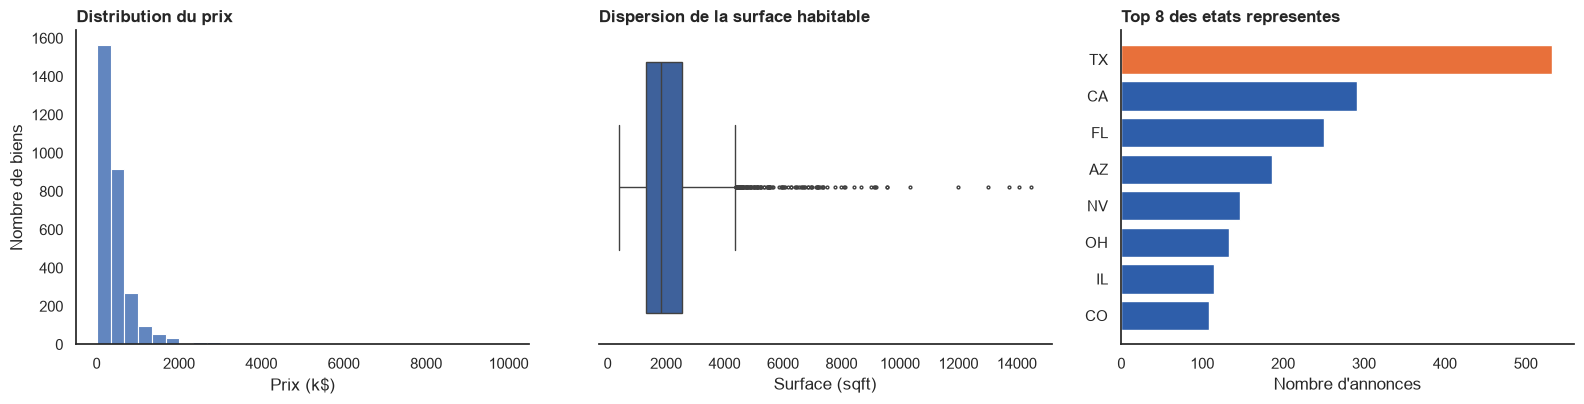

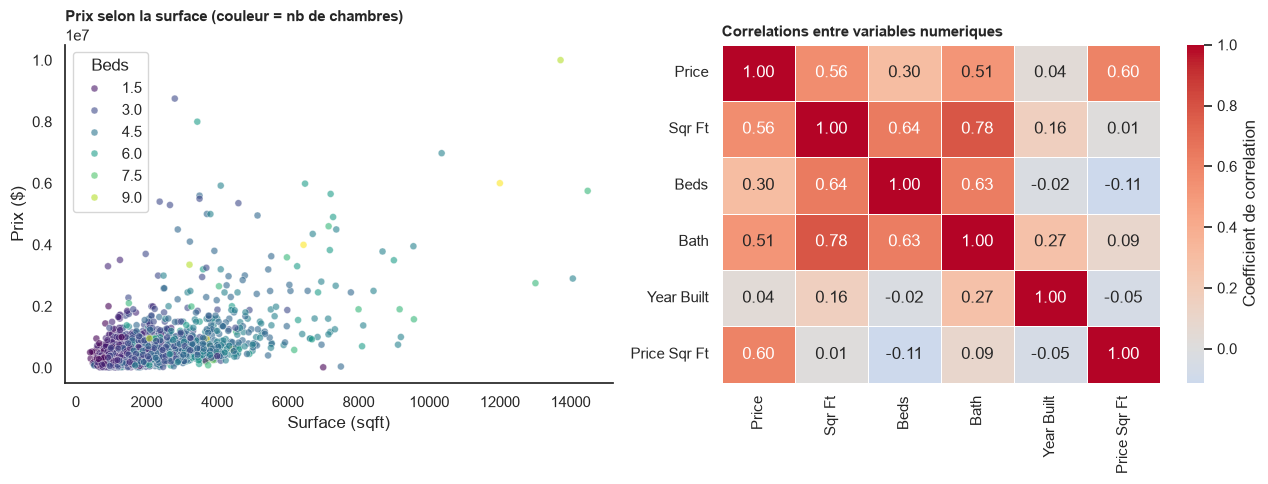

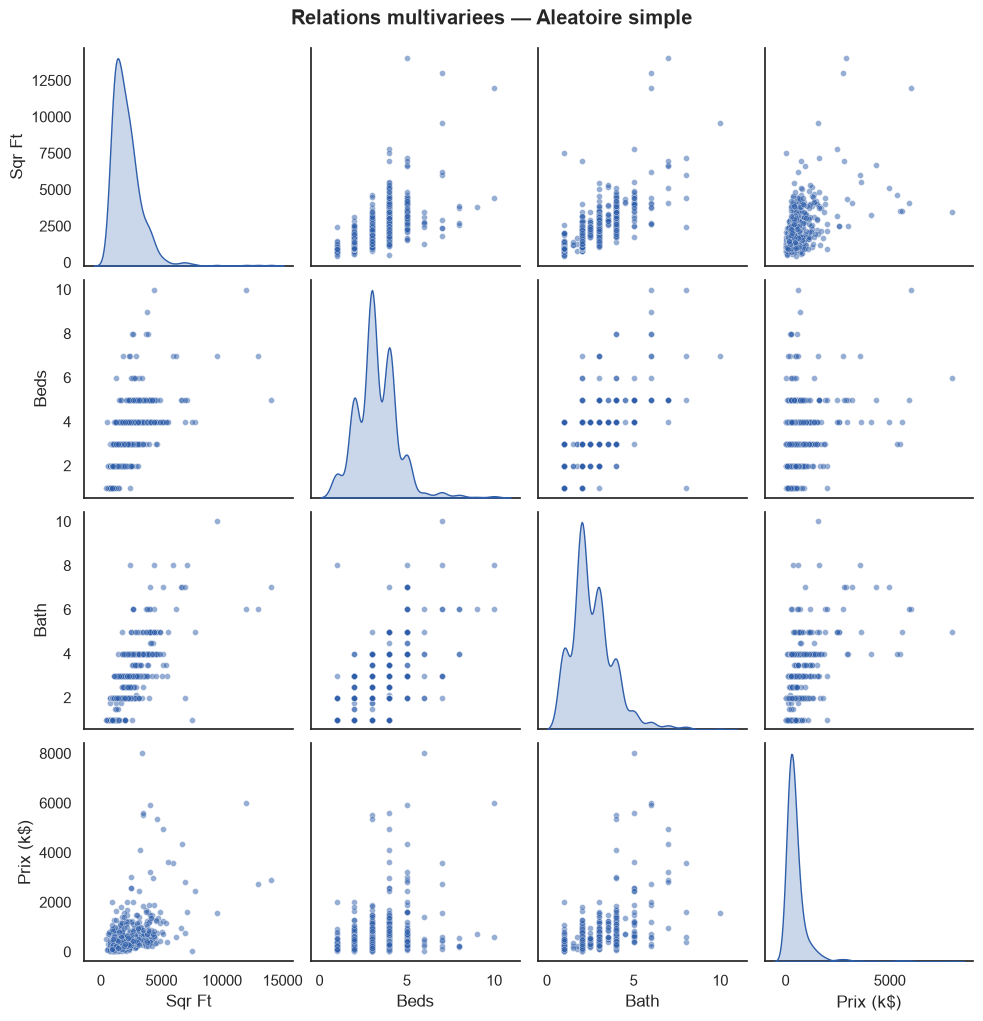

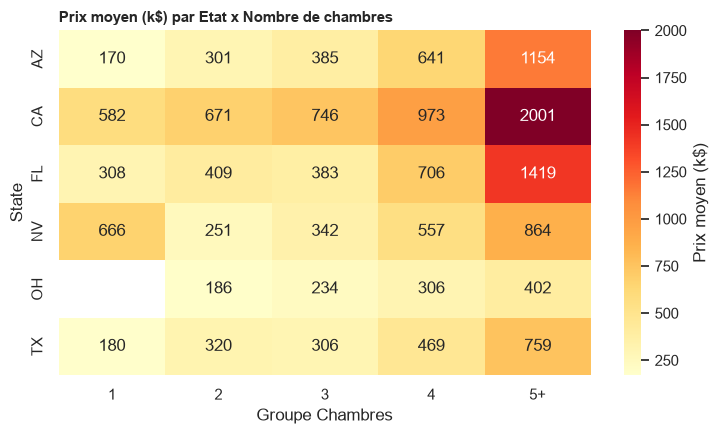

In [19]:
ech_aleatoire = echantillon_aleatoire_simple(df_propre, TAILLE_ECHANTILLON)
stats_aleatoire = analyser_echantillon(ech_aleatoire, "Aleatoire simple")
resultats_comparaison.append(stats_aleatoire)


### 6.2 Échantillon 2 — Stratifié par État

===== Echantillon : Stratifie (Etat)  (n = 3000) =====


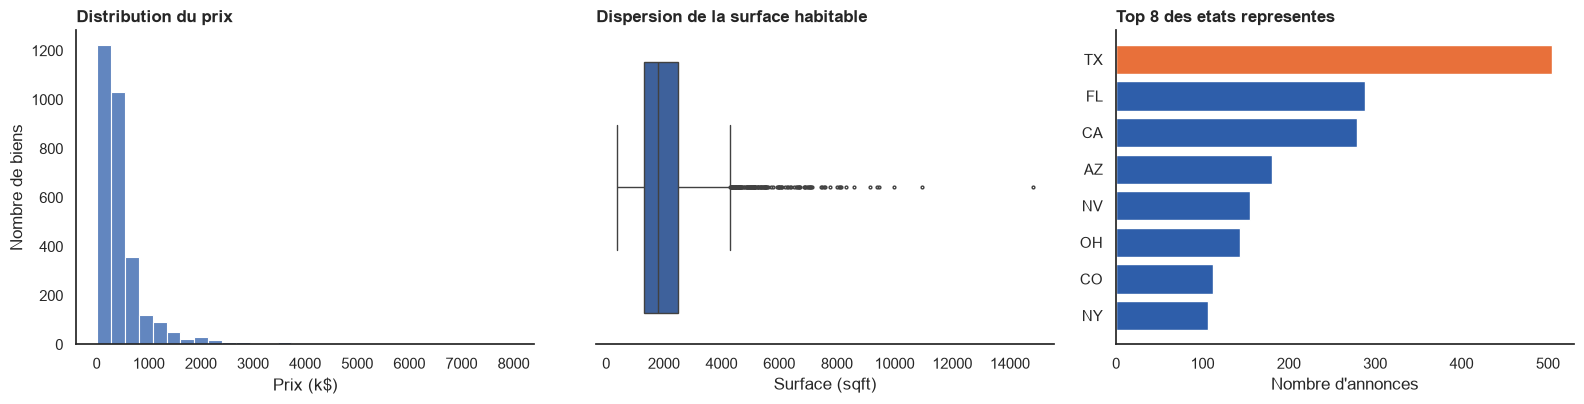

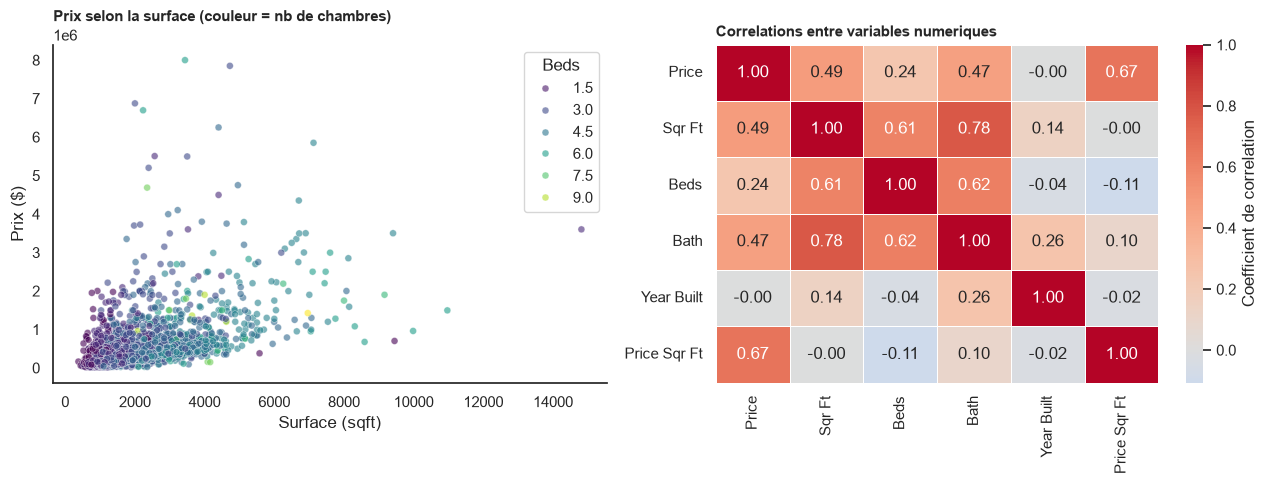

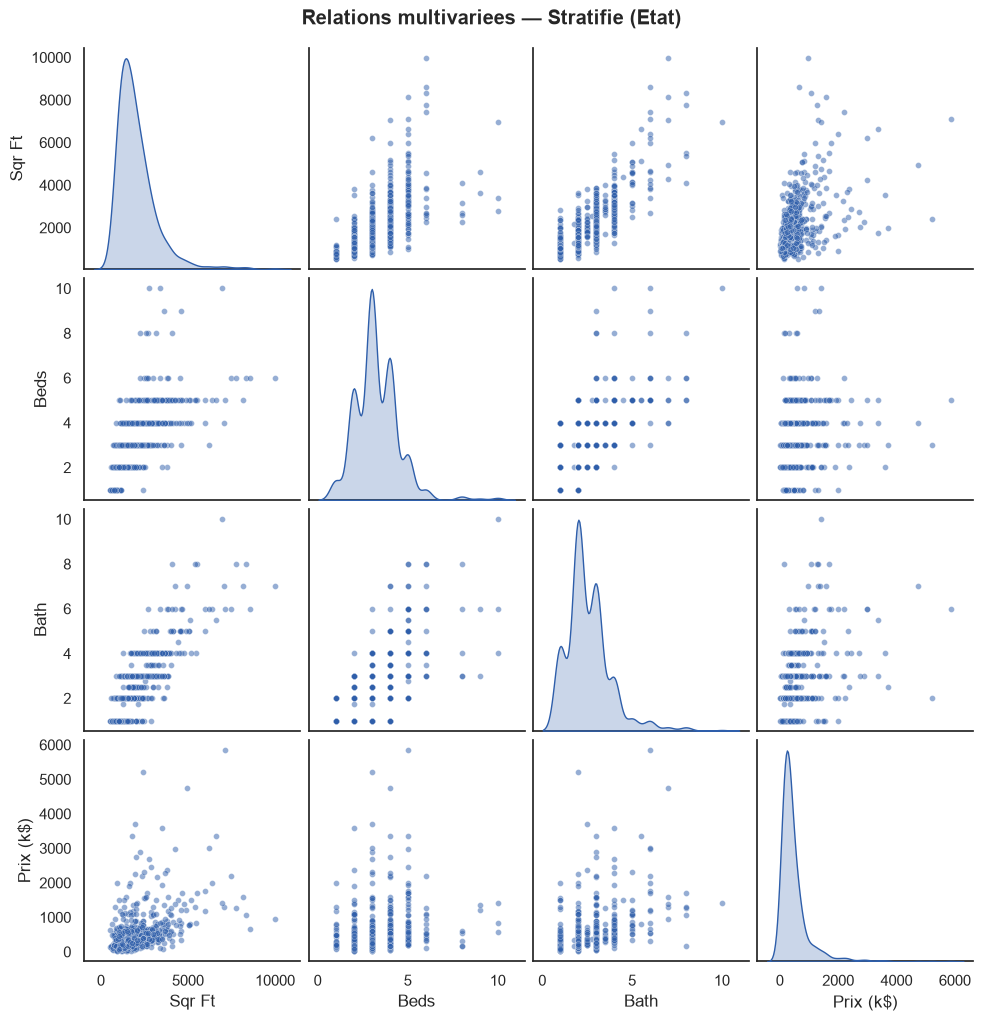

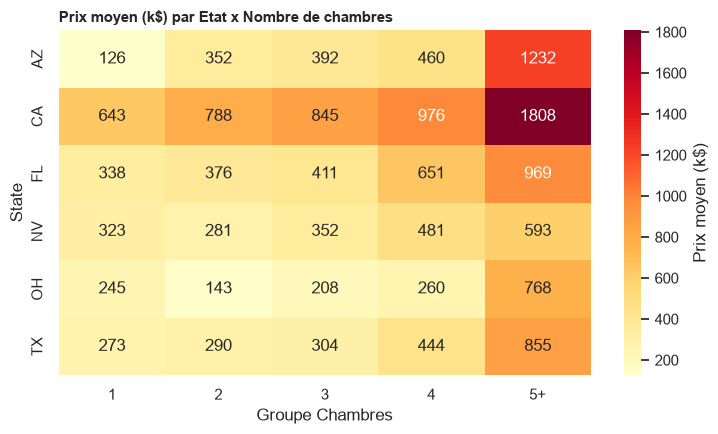

In [20]:
ech_stratifie = echantillon_stratifie(df_propre, 'State', TAILLE_ECHANTILLON)
stats_stratifie = analyser_echantillon(ech_stratifie, "Stratifie (Etat)")
resultats_comparaison.append(stats_stratifie)


### 6.3 Échantillon 3 — Systématique

===== Echantillon : Systematique  (n = 3297) =====


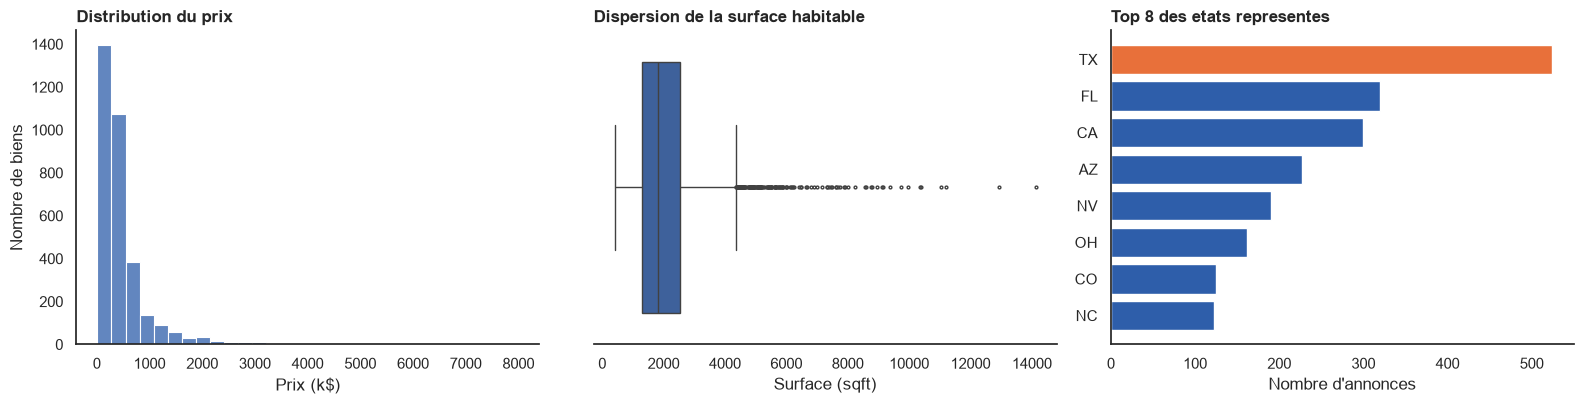

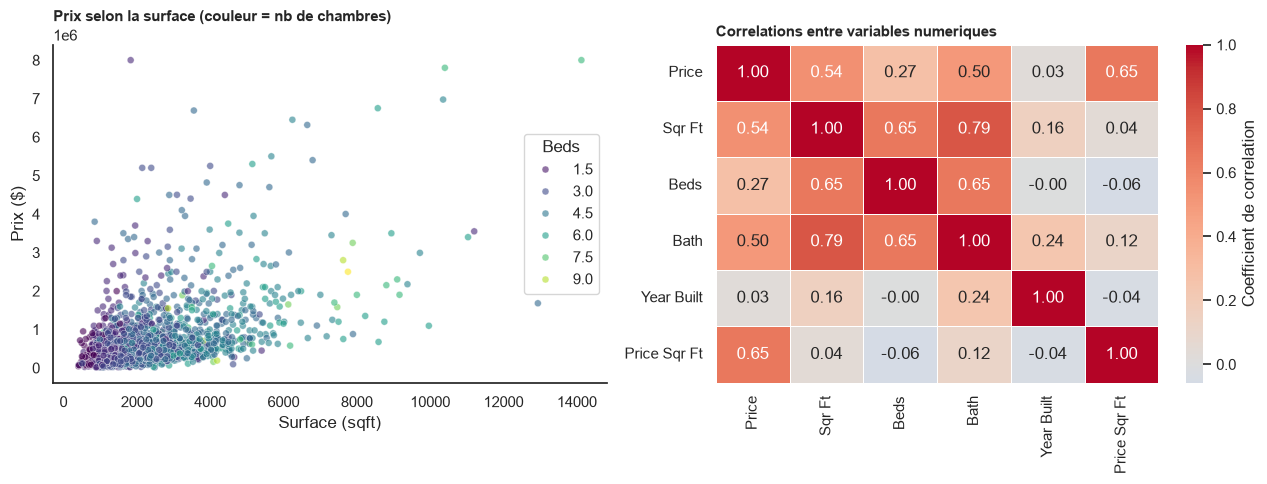

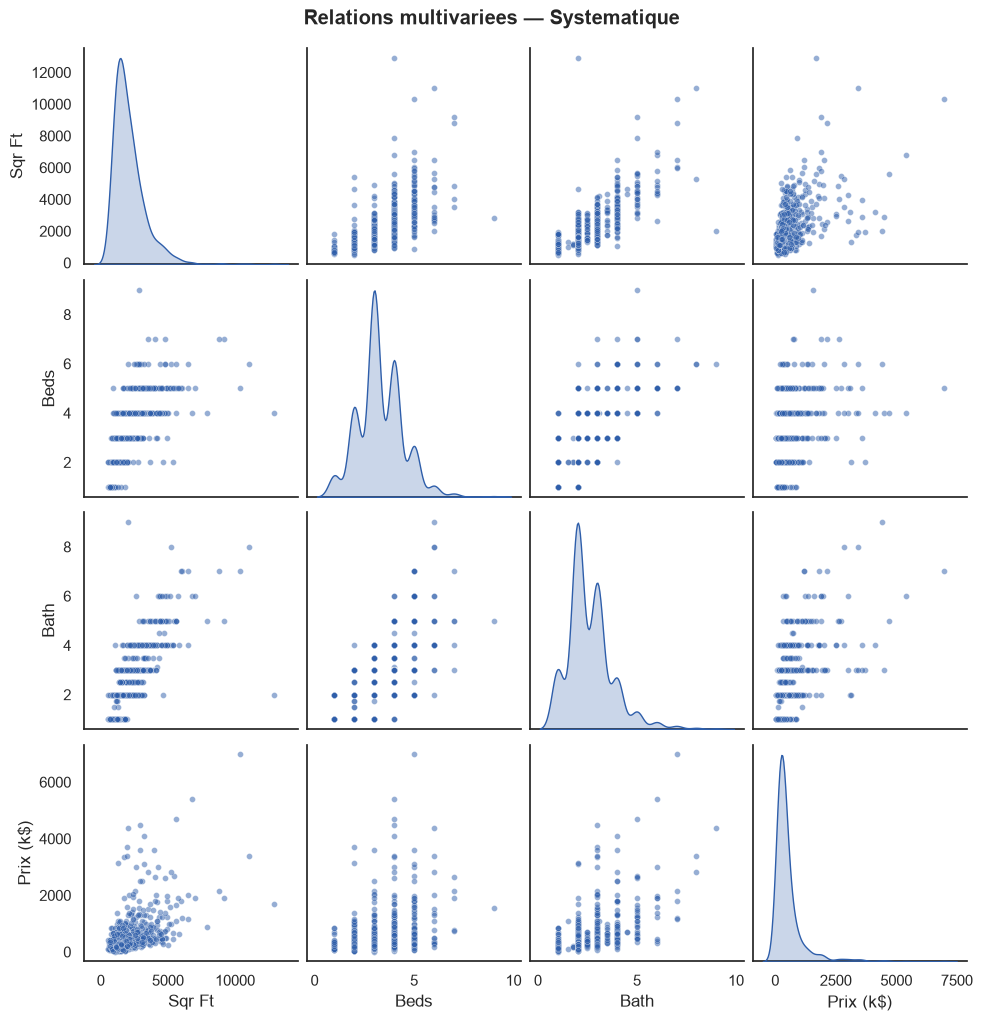

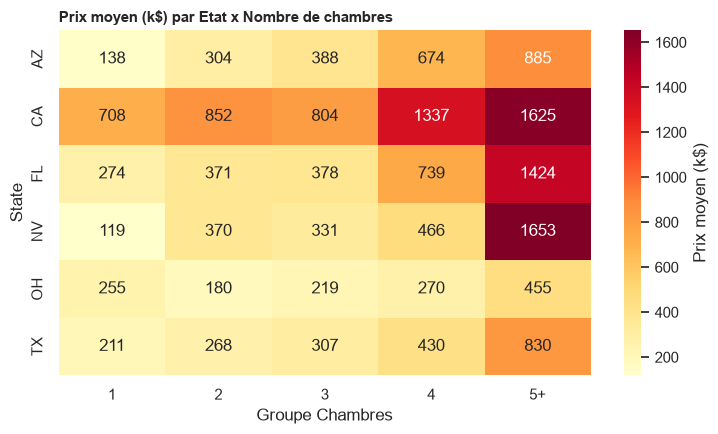

In [21]:
ech_systematique = echantillon_systematique(df_propre, TAILLE_ECHANTILLON)
stats_systematique = analyser_echantillon(ech_systematique, "Systematique")
resultats_comparaison.append(stats_systematique)


### 6.4 Échantillon 4 — En grappes (par ville)

Villes (grappes) tirees au sort : 53
===== Echantillon : Grappes (Ville)  (n = 3087) =====


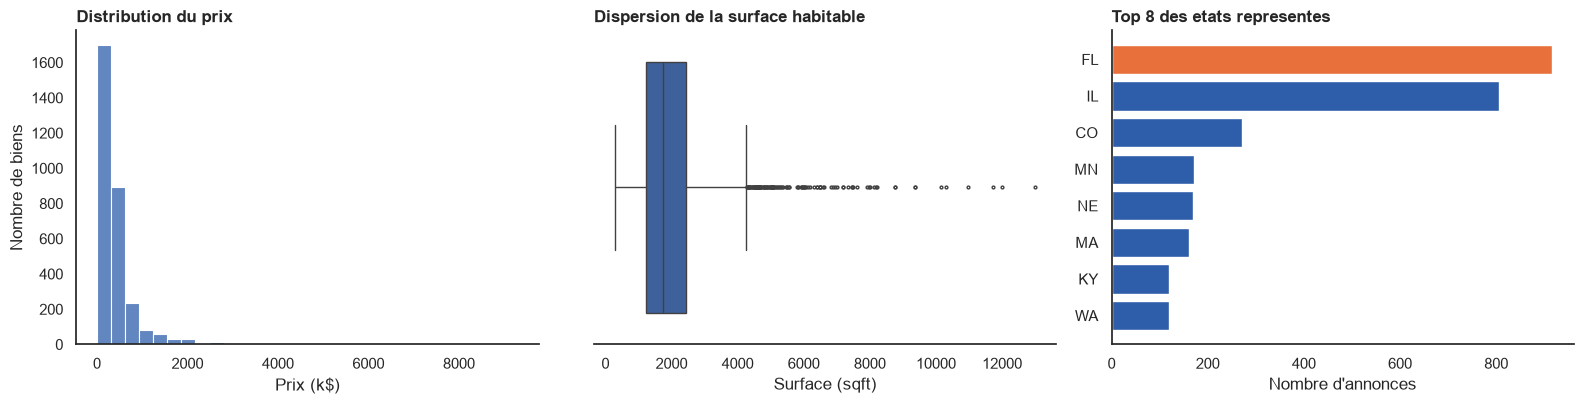

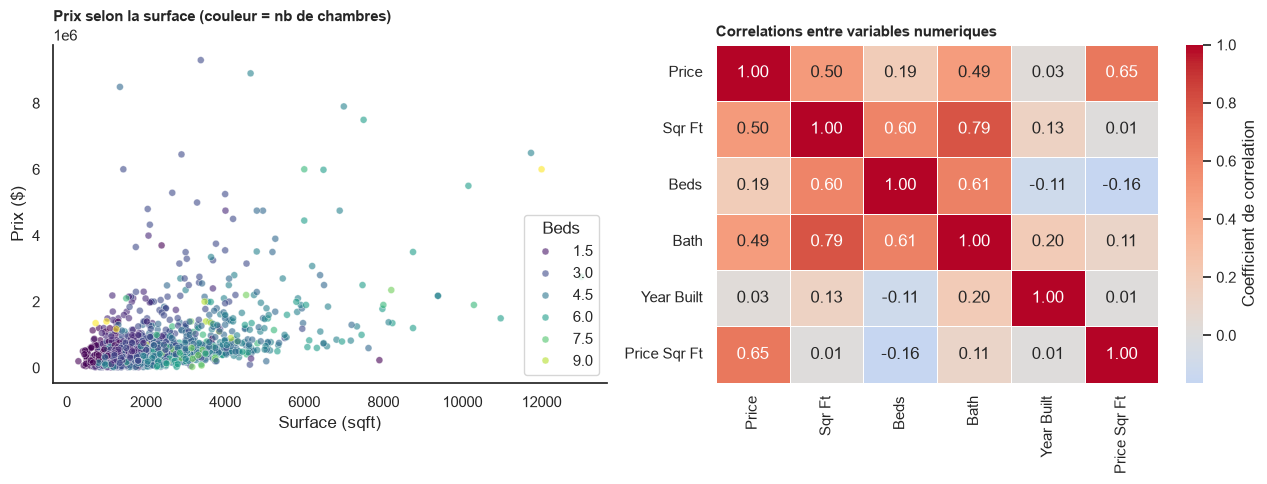

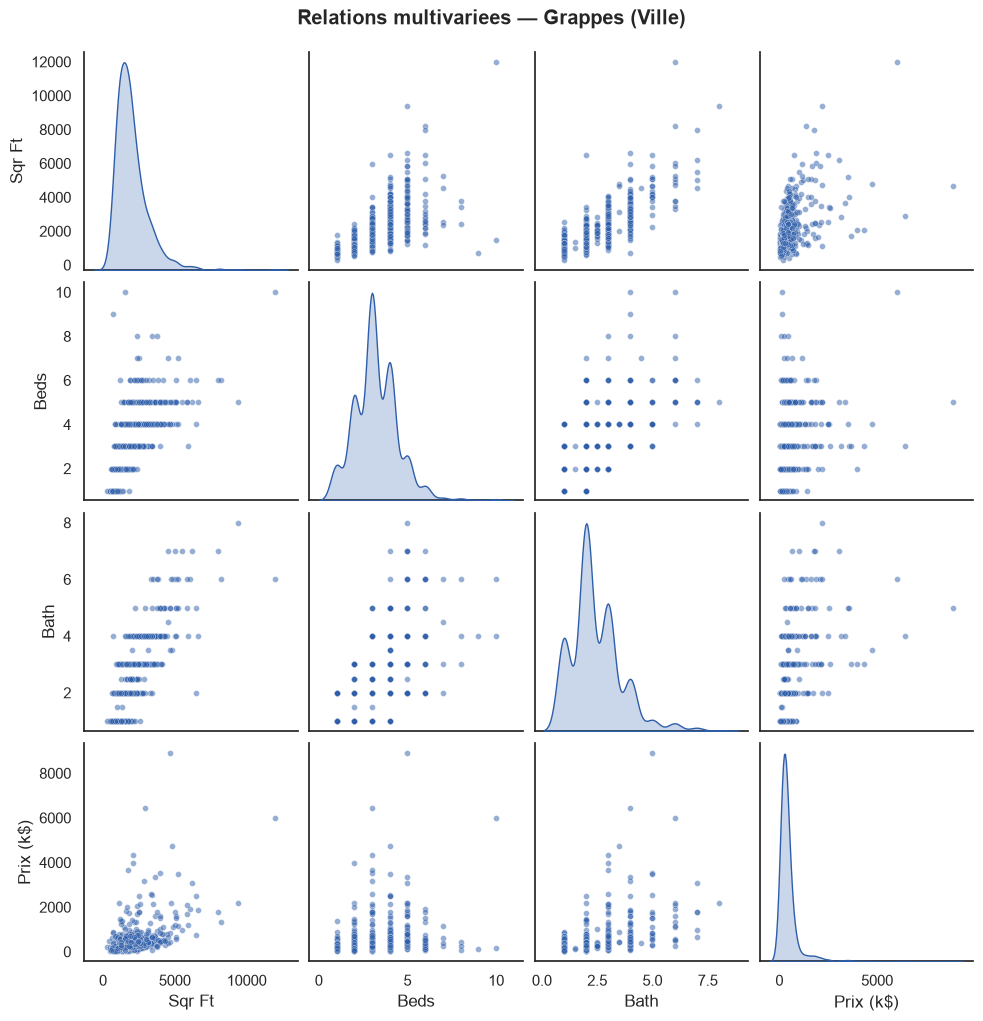

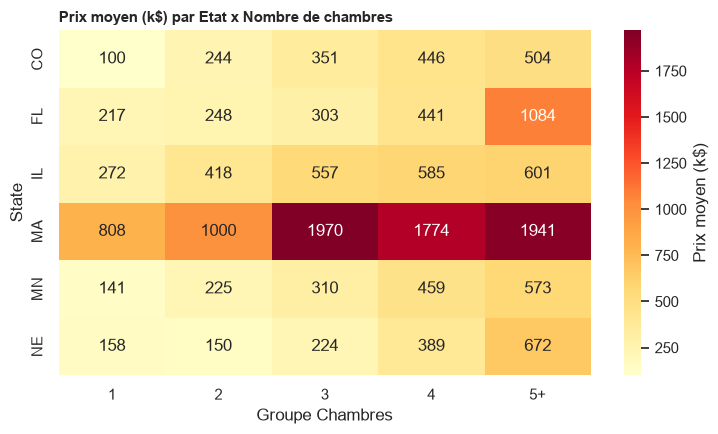

In [22]:
ech_grappes, villes_tirees = echantillon_grappes(df_propre, 'City', TAILLE_ECHANTILLON)
print(f"Villes (grappes) tirees au sort : {len(villes_tirees)}")
stats_grappes = analyser_echantillon(ech_grappes, "Grappes (Ville)")
resultats_comparaison.append(stats_grappes)


### 6.5 Échantillon 5 — Par quotas (segment de prix)

Quotas fixés à l'avance en s'appuyant sur le poids réel de chaque segment dans la population
(cf. graphique de la section 2), tout en gardant un total de 3000 biens.

===== Echantillon : Quotas (Segment Prix)  (n = 3000) =====


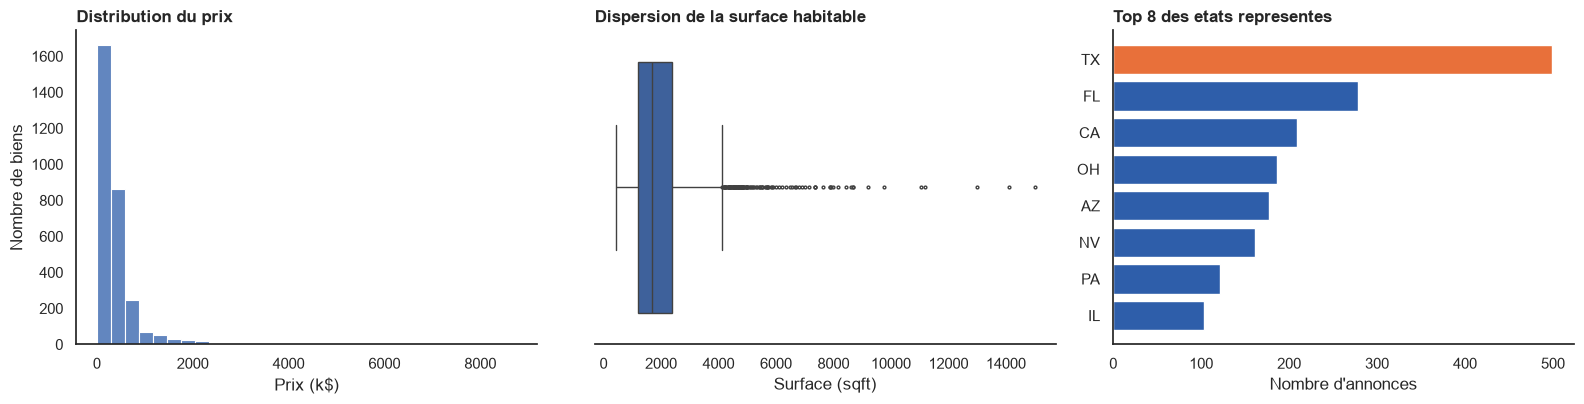

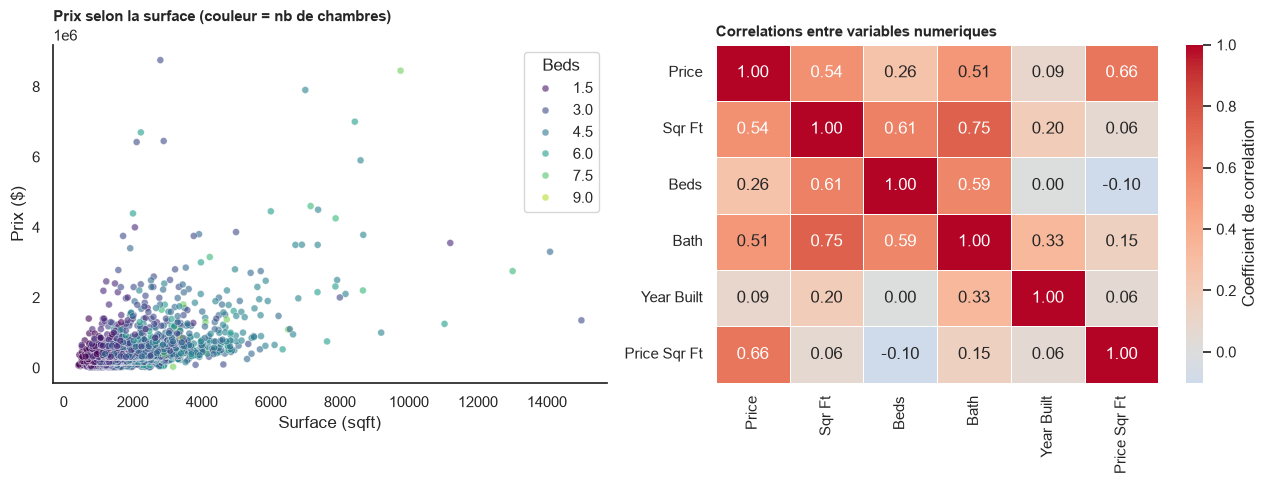

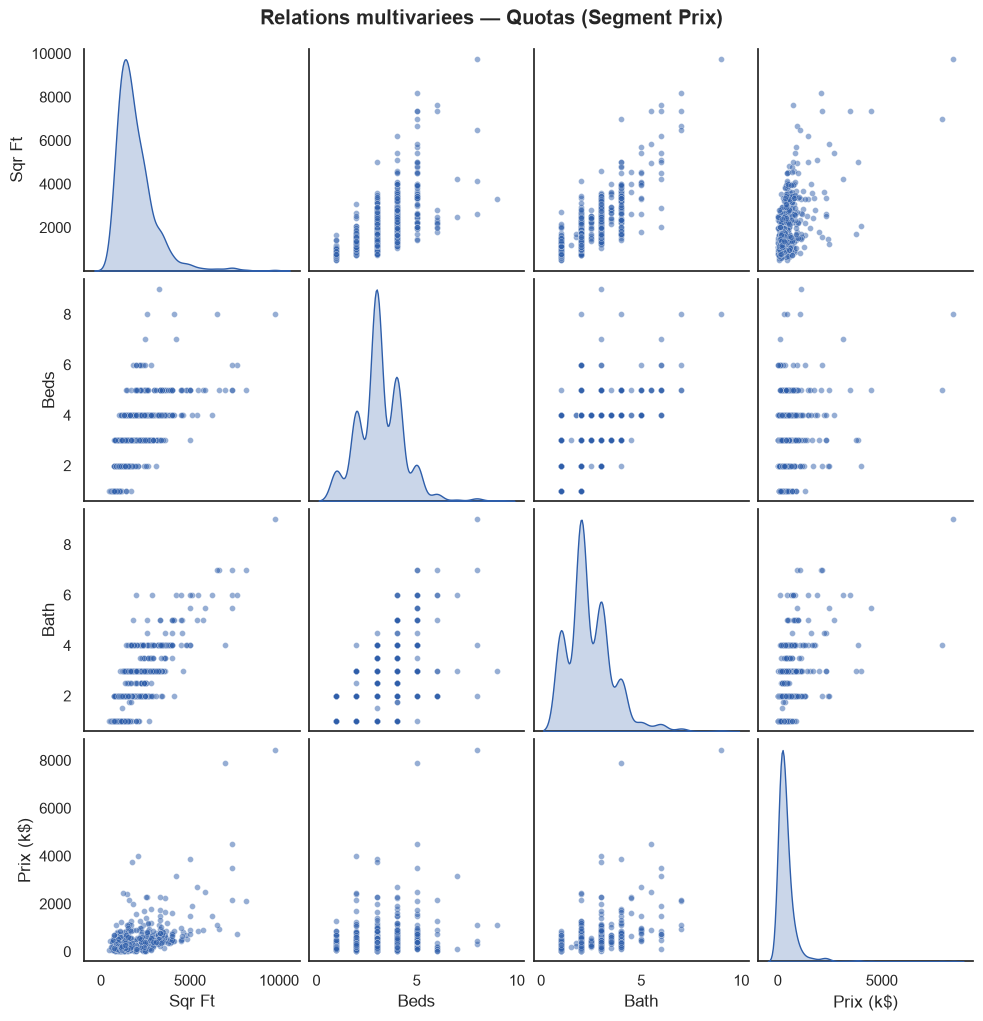

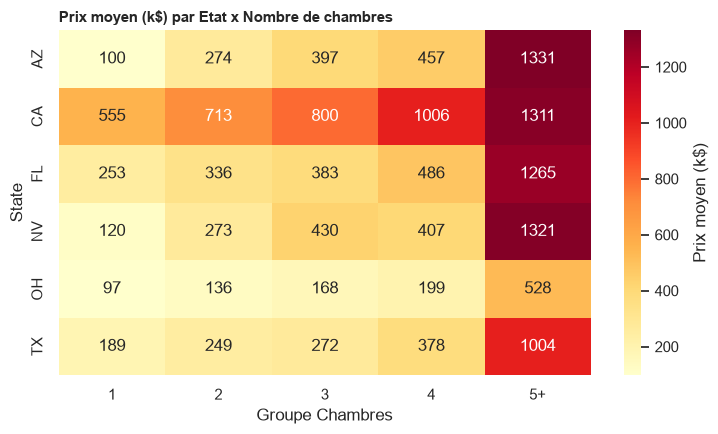

In [23]:
quotas_segments = {'Economique': 750, 'Moyen': 900, 'Superieur': 900, 'Luxe': 450}
ech_quotas = echantillon_quotas(df_propre, 'Segment Prix', quotas_segments)
stats_quotas = analyser_echantillon(ech_quotas, "Quotas (Segment Prix)")
resultats_comparaison.append(stats_quotas)


## 7. Comparaison des 5 méthodes d'échantillonnage

On compare maintenant chaque échantillon à la **population totale** (`df_propre`) sur deux critères :
le prix moyen (indicateur de représentativité) et le nombre d'états couverts (indicateur de diversité
géographique).

In [24]:
prix_moyen_population = df_propre['Price'].mean()

tableau_comparaison = pd.DataFrame(resultats_comparaison)
tableau_comparaison['Biais prix (%)'] = (
    (tableau_comparaison['Prix moyen'] - prix_moyen_population) / prix_moyen_population * 100
)

tableau_comparaison_affiche = tableau_comparaison.copy()
for col in ['Prix moyen', 'Prix median', 'Ecart-type prix', 'Surface moyenne']:
    tableau_comparaison_affiche[col] = tableau_comparaison_affiche[col].round(0)
tableau_comparaison_affiche['Biais prix (%)'] = tableau_comparaison_affiche['Biais prix (%)'].round(2)

print(f"Prix moyen dans la POPULATION TOTALE (n={len(df_propre):,}) : {prix_moyen_population:,.0f} $")
tableau_comparaison_affiche


Prix moyen dans la POPULATION TOTALE (n=26,376) : 503,865 $


,Echantillon,n,Prix moyen,Prix median,Ecart-type prix,Surface moyenne,Nb etats couverts,Biais prix (%)
0,Aleatoire simple,3000,501006.0,325245.0,664076.0,2103.0,34,-0.57
1,Stratifie (Etat),3000,495567.0,326700.0,610334.0,2070.0,34,-1.65
2,Systematique,3297,507328.0,315000.0,670214.0,2093.0,34,0.69
3,Grappes (Ville),3087,460542.0,290000.0,663529.0,2012.0,19,-8.60
4,Quotas (Segment Prix),3000,418085.0,275360.0,585506.0,1954.0,34,-17.02


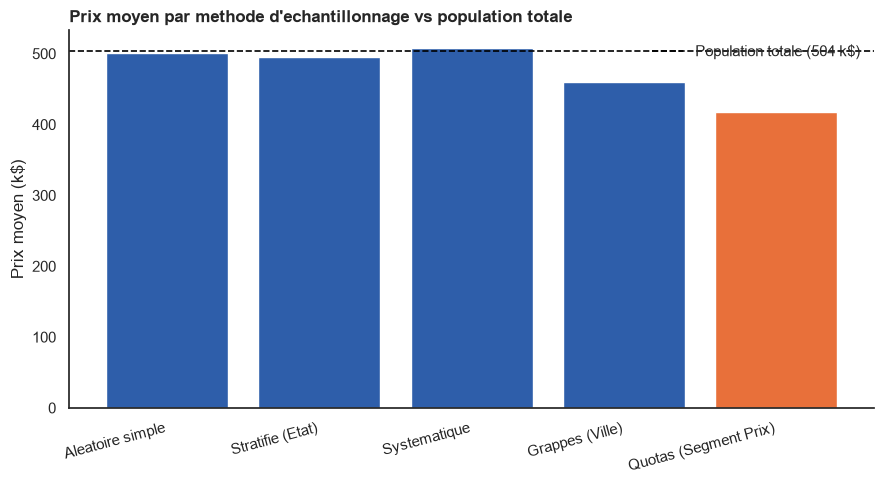

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
couleurs_methodes = [COULEUR_ACCENT if abs(b) == tableau_comparaison['Biais prix (%)'].abs().max()
                      else COULEUR_PRINCIPALE for b in tableau_comparaison['Biais prix (%)']]
ax.bar(tableau_comparaison['Echantillon'], tableau_comparaison['Prix moyen'] / 1000, color=couleurs_methodes)
ax.axhline(prix_moyen_population / 1000, color='black', linestyle='--', linewidth=1.2,
           label=f"Population totale ({prix_moyen_population/1000:.0f} k$)")
ax.set_ylabel("Prix moyen (k$)")
ax.set_title("Prix moyen par methode d'echantillonnage vs population totale",
             fontsize=12, fontweight='bold', loc='left')
ax.legend(frameon=False)
plt.xticks(rotation=15, ha='right')
sns.despine(ax=ax)
plt.tight_layout(); plt.show()


### 7.1 Lecture des résultats

Sur ce jeu de données (population totale : prix moyen ≈ **503 865 $**) :

- **Aléatoire simple** (biais ≈ **-0,6 %**) et **Systématique** (biais ≈ **+0,7 %**) sont les deux méthodes
  les plus proches de la population totale — ce qui est attendu, car ce sont les deux seules méthodes
  purement probabilistes qui ne cherchent pas à modifier volontairement la structure de l'échantillon.
- **Stratifié par État** reste très proche (biais ≈ **-1,6 %**) et présente un avantage supplémentaire :
  il **garantit** la présence des 34 états dans l'échantillon avec un poids proportionnel à leur
  importance réelle, ce que l'aléatoire simple ne garantit pas toujours pour les petits états.
- **En grappes (par ville)** montre un biais plus marqué (≈ **-8,6 %**) et surtout **ne couvre que
  19 états sur 34** : en tirant des villes entières plutôt que des biens individuels, on perd
  mécaniquement en diversité géographique — c'est la limite classique de cette méthode.
- **Par quotas (segment de prix)** affiche le biais le plus important (≈ **-17 %**) : les quotas fixés
  (750/900/900/450) ne respectent pas exactement les proportions réelles des segments dans la
  population, ce qui illustre bien le caractère **non probabiliste** de cette méthode — utile pour
  garantir un nombre minimum d'observations dans chaque catégorie (ex : le segment "Luxe", plus rare),
  mais au prix d'une représentativité globale moindre.

**Conclusion intermédiaire :** pour une estimation non biaisée du prix moyen du marché, les méthodes
**aléatoire simple**, **systématique** ou **stratifiée** sont préférables. L'échantillonnage en grappes
ou par quotas reste pertinent pour des objectifs différents (réduire les coûts de collecte, garantir un
volume minimal dans une sous-catégorie rare) mais nécessite d'être conscient du biais introduit.

## 8. Synthèse, limites et recommandations

### 8.1 Principaux insights
- Le prix est **positivement corrélé** à la surface habitable (`Sqr Ft`) et au nombre de salles de bain
  (`Bath`), corrélations les plus fortes du dataset — cohérent avec l'intuition métier.
- De fortes **disparités géographiques** existent : la Californie affiche un prix moyen très supérieur
  aux autres états du Top 6, quel que soit le nombre de chambres, alors que l'Ohio reste nettement plus
  abordable.
- La variable `Year Built` est peu corrélée au prix : l'ancienneté du bien ne semble pas être, à elle
  seule, un facteur déterminant sur ce marché et cette période.
- Les états **Texas, Californie et Floride** dominent largement le volume d'annonces (près de 34 % des
  biens à eux trois), ce qui reflète surtout l'intensité de la collecte Trulia dans ces marchés plus que
  la réalité démographique du pays.

### 8.2 Limites du dataset et de l'analyse
- **Période courte** (2 mois, sept-oct 2019) : les résultats ne peuvent pas être généralisés à d'autres
  saisons ou années, notamment pas à la période post-2020 (Covid, hausse des taux...).
- **Mélange initial ventes/locations** repéré et corrigé, mais seule la mention explicite `/mo` a pu être
  détectée automatiquement ; quelques annonces mal étiquetées ont pu subsister.
- **Colonne `Property Type` inexploitable** (99,7 % de valeurs manquantes) : on ne peut pas distinguer
  maison individuelle, appartement, etc., ce qui limite la finesse de l'analyse.
- **Sur-représentation de certains états** (Texas, Californie, Floride) due au mode de collecte
  (scraping), et non à un plan d'échantillonnage contrôlé à la source.
- Les bornes de nettoyage des valeurs aberrantes (ex. prix entre 10 000 $ et 10 000 000 $) reposent sur un
  jugement métier raisonnable mais **arbitraire** ; d'autres seuils auraient pu être retenus.

### 8.3 Recommandations
1. Pour une étude de marché fiable, **privilégier un échantillonnage stratifié par État** : il offre le
   meilleur compromis entre représentativité globale et couverture géographique garantie.
2. Compléter le dataset avec le **type de bien** (maison/appartement/condo) pour affiner l'analyse.
3. Étendre la période de collecte sur au moins 12 mois pour capter les effets saisonniers du marché
   immobilier.
4. Pour le tableau de bord (section 9), permettre à l'utilisateur de **choisir lui-même sa méthode
   d'échantillonnage** afin de visualiser concrètement l'effet du biais étudié en section 7.

## 9. Tableau de bord interactif

Le tableau de bord est fourni **en dehors du notebook**, dans un fichier `app_dashboard.py` autonome,
car les librairies de dashboard (Streamlit) ne s'exécutent pas à l'intérieur d'un notebook classique.

### 9.1 Cahier des charges du dashboard
En cohérence avec l'annexe « Bonnes pratiques » du sujet :
- **KPIs en haut** : nombre de biens filtrés, prix moyen, prix médian, surface moyenne.
- **Filtres dynamiques** dans la barre latérale : État(s), méthode d'échantillonnage (aléatoire simple /
  stratifié / systématique / grappes / quotas), plage de prix, nombre de chambres.
- **Graphiques liés** : ils se recalculent tous automatiquement quand un filtre change.
- **Thème de couleur cohérent** avec celui du notebook (bleu principal / orange d'accentuation).
- **Labels clairs**, titres explicites, une seule idée par graphique.

### 9.2 Génération des fichiers du dashboard
Les deux cellules suivantes utilisent la commande `%%writefile` pour **écrire directement sur le
disque** le script du dashboard et son fichier de dépendances. Il suffit ensuite d'exécuter, dans un
terminal (pas dans le notebook) :

```bash
pip install -r requirements_dashboard.txt
streamlit run app_dashboard.py
```

> 💡 Le dashboard recharge et nettoie lui-même `marketing_sample_for_trulia_com-real_estate__20190901_20191031__30k_data.csv`
> (même logique de nettoyage que les sections 1-2 de ce notebook) : placez ce fichier CSV dans le même
> dossier que `app_dashboard.py`.

In [26]:
%%writefile requirements_dashboard.txt
streamlit>=1.30
pandas>=2.0
numpy>=1.24
plotly>=5.18


Writing requirements_dashboard.txt


In [27]:
%%writefile app_dashboard.py
# ============================================================================
# Tableau de bord interactif - Marche immobilier Trulia (sept-oct 2019)
# Lancer avec : streamlit run app_dashboard.py
# ============================================================================
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px

st.set_page_config(page_title="Dashboard Immobilier Trulia", layout="wide", page_icon="🏠")

COULEUR_PRINCIPALE = "#2E5EAA"
COULEUR_ACCENT = "#E8703A"
PALETTE = [COULEUR_PRINCIPALE, "#6FA8DC", "#93C47D", "#D5A6BD", "#F1C232", "#8E7CC3"]

CSV_PATH = "marketing_sample_for_trulia_com-real_estate__20190901_20191031__30k_data.csv"


# ----------------------------------------------------------------------------
# Chargement + nettoyage (mise en cache : n'est recalcule que si le fichier change)
# ----------------------------------------------------------------------------
@st.cache_data
def charger_et_nettoyer(chemin):
    colonnes_utiles = [
        'Uniq Id', 'Price', 'Sqr Ft', 'Longitude', 'Latitude', 'Lot Size', 'Beds', 'Bath',
        'Year Built', 'Price Sqr Ft', 'Last Sold Year', 'Last Sold For', 'City', 'State',
        'Zipcode', 'Days On Trulia'
    ]
    df = pd.read_csv(chemin, usecols=colonnes_utiles, low_memory=False)

    df['Est_Location'] = df['Price'].astype(str).str.contains('/mo', na=False)
    prix = (df['Price'].astype(str)
            .str.replace(r'[\$,+]', '', regex=True)
            .str.replace('/mo', '', regex=False))
    df['Price'] = pd.to_numeric(prix, errors='coerce')
    df['Sqr Ft'] = pd.to_numeric(
        df['Sqr Ft'].astype(str).str.replace(',', '', regex=False).str.replace('sqft', '', regex=False),
        errors='coerce')

    bornes = {
        'Price': (10_000, 10_000_000), 'Sqr Ft': (200, 15_000),
        'Beds': (1, 10), 'Bath': (1, 10), 'Year Built': (1800, 2019),
    }
    for col, (lo, hi) in bornes.items():
        df.loc[(df[col] < lo) | (df[col] > hi), col] = np.nan

    df = df[~df['Est_Location']].copy()
    df = df.dropna(subset=['Price', 'Sqr Ft', 'Beds', 'Bath', 'State', 'City', 'Latitude', 'Longitude'])

    def segmenter(p):
        if p < 150_000: return 'Economique'
        elif p < 300_000: return 'Moyen'
        elif p < 600_000: return 'Superieur'
        return 'Luxe'
    df['Segment Prix'] = df['Price'].apply(segmenter)
    return df.reset_index(drop=True)


def tirer_echantillon(df, methode, taille, seed=42):
    '''Applique la methode d'echantillonnage choisie par l'utilisateur (memes fonctions que le notebook).'''
    taille = min(taille, len(df))
    if methode == "Population complete (pas d'echantillonnage)":
        return df
    if methode == "Aleatoire simple":
        return df.sample(n=taille, random_state=seed)
    if methode == "Stratifie (par Etat)":
        fraction = taille / len(df)
        parts = [g.sample(n=min(max(1, round(len(g) * fraction)), len(g)), random_state=seed)
                 for _, g in df.groupby('State', observed=True)]
        return pd.concat(parts)
    if methode == "Systematique":
        pas_k = max(1, len(df) // taille)
        rng = np.random.default_rng(seed)
        depart = rng.integers(0, pas_k)
        return df.iloc[np.arange(depart, len(df), pas_k)]
    if methode == "En grappes (par ville)":
        rng = np.random.default_rng(seed)
        villes = df['City'].unique().tolist()
        ordre = rng.permutation(len(villes))
        morceaux, total = [], 0
        for i in ordre:
            bloc = df[df['City'] == villes[i]]
            morceaux.append(bloc); total += len(bloc)
            if total >= taille:
                break
        return pd.concat(morceaux)
    if methode == "Par quotas (segment de prix)":
        quotas = {'Economique': 0.25, 'Moyen': 0.30, 'Superieur': 0.30, 'Luxe': 0.15}
        morceaux = []
        for seg, part in quotas.items():
            bloc = df[df['Segment Prix'] == seg]
            q = min(int(taille * part), len(bloc))
            if q > 0:
                morceaux.append(bloc.sample(n=q, random_state=seed))
        return pd.concat(morceaux)
    return df


# ----------------------------------------------------------------------------
# Chargement des donnees
# ----------------------------------------------------------------------------
try:
    df_source = charger_et_nettoyer(CSV_PATH)
except FileNotFoundError:
    st.error(f"Fichier introuvable : {CSV_PATH}. Placez le CSV a cote de app_dashboard.py.")
    st.stop()

# ----------------------------------------------------------------------------
# BARRE LATERALE : filtres dynamiques
# ----------------------------------------------------------------------------
st.sidebar.header("🎛️ Filtres")

methode_ech = st.sidebar.selectbox(
    "Methode d'echantillonnage",
    ["Population complete (pas d'echantillonnage)", "Aleatoire simple", "Stratifie (par Etat)",
     "Systematique", "En grappes (par ville)", "Par quotas (segment de prix)"],
    help="Compare l'effet de chaque methode vue en cours sur les indicateurs affiches.",
)
taille_ech = st.sidebar.slider("Taille de l'echantillon", 500, min(10000, len(df_source)), 3000, step=500)

etats_dispo = sorted(df_source['State'].unique())
etats_choisis = st.sidebar.multiselect("Etat(s)", etats_dispo, default=[])

prix_min, prix_max = int(df_source['Price'].min()), int(df_source['Price'].max())
plage_prix = st.sidebar.slider("Fourchette de prix ($)", prix_min, prix_max, (prix_min, prix_max), step=5000)

chambres_min, chambres_max = int(df_source['Beds'].min()), int(df_source['Beds'].max())
plage_chambres = st.sidebar.slider("Nombre de chambres", chambres_min, chambres_max,
                                    (chambres_min, chambres_max))

# ----------------------------------------------------------------------------
# Application de l'echantillonnage PUIS des filtres (dans cet ordre, comme dans le notebook)
# ----------------------------------------------------------------------------
df_ech = tirer_echantillon(df_source, methode_ech, taille_ech)

df_filtre = df_ech[
    (df_ech['Price'].between(*plage_prix)) & (df_ech['Beds'].between(*plage_chambres))
]
if etats_choisis:
    df_filtre = df_filtre[df_filtre['State'].isin(etats_choisis)]

# ----------------------------------------------------------------------------
# EN-TETE + KPIs (hierarchie visuelle : l'essentiel en premier, en haut)
# ----------------------------------------------------------------------------
st.title("🏠 Marché immobilier Trulia — Tableau de bord interactif")
st.caption("Annonces collectées entre le 01/09/2019 et le 31/10/2019 — 34 états, 676 villes")

if df_filtre.empty:
    st.warning("Aucun bien ne correspond a ces filtres. Elargissez la selection.")
    st.stop()

col1, col2, col3, col4 = st.columns(4)
col1.metric("Biens affichés", f"{len(df_filtre):,}")
col2.metric("Prix moyen", f"{df_filtre['Price'].mean():,.0f} $")
col3.metric("Prix médian", f"{df_filtre['Price'].median():,.0f} $")
col4.metric("Surface moyenne", f"{df_filtre['Sqr Ft'].mean():,.0f} sqft")

st.divider()

# ----------------------------------------------------------------------------
# GRAPHIQUES LIES (se recalculent automatiquement selon les filtres actifs)
# ----------------------------------------------------------------------------
ligne1_gauche, ligne1_droite = st.columns(2)

with ligne1_gauche:
    fig_hist = px.histogram(df_filtre, x="Price", nbins=40,
                             title="Distribution du prix",
                             color_discrete_sequence=[COULEUR_PRINCIPALE])
    fig_hist.update_layout(xaxis_title="Prix ($)", yaxis_title="Nombre de biens",
                            title_font=dict(size=16))
    st.plotly_chart(fig_hist, use_container_width=True)

with ligne1_droite:
    prix_par_etat = (df_filtre.groupby('State', observed=True)['Price'].mean()
                      .sort_values(ascending=False).head(10).reset_index())
    couleurs = [COULEUR_ACCENT if i == 0 else COULEUR_PRINCIPALE for i in range(len(prix_par_etat))]
    fig_bar = px.bar(prix_par_etat, x="Price", y="State", orientation="h",
                      title="Top 10 des états par prix moyen",
                      color_discrete_sequence=[COULEUR_PRINCIPALE])
    fig_bar.update_traces(marker_color=couleurs)
    fig_bar.update_layout(yaxis=dict(autorange="reversed"), xaxis_title="Prix moyen ($)", yaxis_title="")
    st.plotly_chart(fig_bar, use_container_width=True)

ligne2_gauche, ligne2_droite = st.columns(2)

with ligne2_gauche:
    fig_scatter = px.scatter(df_filtre, x="Sqr Ft", y="Price", color="Beds",
                              title="Prix selon la surface (couleur = nb chambres)",
                              color_continuous_scale="viridis", opacity=0.6)
    fig_scatter.update_layout(xaxis_title="Surface (sqft)", yaxis_title="Prix ($)")
    st.plotly_chart(fig_scatter, use_container_width=True)

with ligne2_droite:
    fig_carte = px.scatter_mapbox(
        df_filtre, lat="Latitude", lon="Longitude", color="Price", size_max=10, zoom=2.8,
        color_continuous_scale="Bluered", mapbox_style="carto-positron",
        title="Répartition géographique des biens", hover_data={"City": True, "Price": True},
    )
    fig_carte.update_layout(margin=dict(l=0, r=0, t=40, b=0))
    st.plotly_chart(fig_carte, use_container_width=True)

st.divider()
fig_box = px.box(df_filtre, x="Segment Prix", y="Price", color="Segment Prix",
                  category_orders={"Segment Prix": ["Economique", "Moyen", "Superieur", "Luxe"]},
                  color_discrete_sequence=PALETTE,
                  title="Dispersion du prix par segment")
fig_box.update_layout(showlegend=False, xaxis_title="", yaxis_title="Prix ($)")
st.plotly_chart(fig_box, use_container_width=True)

st.caption(
    "Méthode d'échantillonnage active : **" + methode_ech + "** — "
    "comparez les KPIs ci-dessus en changeant de méthode pour visualiser le biais "
    "étudié dans la section 7 du notebook."
)


Writing app_dashboard.py


### 9.3 Aperçu du résultat attendu

Une fois lancé, le dashboard permet de :
- **basculer entre les 5 méthodes d'échantillonnage** (menu déroulant) et observer en temps réel
  l'effet sur les KPIs (prix moyen, médiane...), ce qui rend concret le travail de comparaison de la
  section 7 ;
- filtrer par état, fourchette de prix et nombre de chambres, avec des graphiques qui se mettent
  à jour automatiquement (histogramme, top des états, nuage de points, carte géographique, boxplot
  par segment) ;
- conserver la **même charte graphique** (bleu principal / orange d'accentuation) que ce notebook,
  pour une continuité visuelle entre l'analyse exploratoire et le dashboard final.

---

## Conclusion générale

Ce notebook a permis de mener une analyse exploratoire complète du marché immobilier américain à
l'automne 2019 à partir des données Trulia, en s'appuyant sur **5 méthodes d'échantillonnage**
différentes appliquées à une population nettoyée de plus de 26 000 annonces. La comparaison des
méthodes confirme que l'échantillonnage aléatoire simple, systématique et stratifié offrent les
meilleures garanties de représentativité, tandis que l'échantillonnage en grappes et par quotas,
bien qu'utiles dans certains contextes pratiques, introduisent un biais plus important qu'il convient
de documenter. Le tableau de bord interactif livré en complément permet à tout utilisateur de
reproduire et d'explorer lui-même ces constats.